# 1. ĐỌC DỮ LIỆU

In [3]:
from google.colab import drive
drive.mount('/content/ggdrive')

Drive already mounted at /content/ggdrive; to attempt to forcibly remount, call drive.mount("/content/ggdrive", force_remount=True).


In [4]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv("/content/ggdrive/MyDrive/DATA ANALYST/PROJECT/1.SUPERSTORE/Sample - Superstore.csv", encoding='latin1')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [5]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# 2. LÀM SẠCH DỮ LIỆU

In [6]:
# KIẾM TRA NAN
print(df.shape)
print(df.isna().sum())
df[df.isna().any(axis=1)]
#không có dữ liệu chứa NaN

(9994, 21)
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [7]:
# KIỂM TRA DUPLICATE
df.duplicated().sum()
#không bị trùng

np.int64(0)

In [8]:
# ĐỊNH DẠNG NGÀY THÁNG
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [9]:
# TẠO BIẾN THỜI GIAN
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
# để dễ thao tác về thời gian


In [10]:
#TẠO BIẾN NGÀY GIAO HÀNG --> xem ngày giao hàng trung bình
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [11]:
df.to_excel('/content/ggdrive/MyDrive/DATA ANALYST/PROJECT/1.SUPERSTORE/data_clear.xlsx', index=False)

# 3. KIỂM TRA OUTLIER

## 3.1 Kiểm tra outlier Doanh số

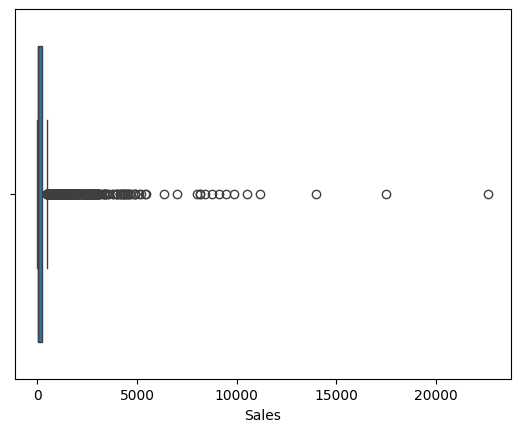

In [15]:
# OUTLIER DOANH SỐ
sns.boxplot(x=df['Sales'])
plt.show()
# doanh số có sai lệch lớn --> có một vài đơn hàng chiếm doanh số lớn (lệch phải)


In [16]:
# Xác định ngưỡng Outlier
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-271.71000000000004 498.93


In [17]:
#Lọc các Outlier
sales_outliers = df[df['Sales'] > upper]
print(sales_outliers.shape)
print(sales_outliers.head())
sales_outliers.to_excel('/content/ggdrive/MyDrive/DATA ANALYST/PROJECT/1.SUPERSTORE/sales_outliers.xlsx', index=False)

print("Đã lưu file sales_outliers.xlsx")
# tìm ra 1167 doành ngoại lai lớn lơn upper trên tổng số 9994 đơn hàng
# --> tìm các đơn hàng này nằm gồm các khách hàng nào --> xếp khách hàng vào VIP --> lưu thành 1 file

(1167, 25)
    Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
1        2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
3        4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
7        8  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
10      11  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
11      12  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   

      Customer Name   Segment        Country             City  ...  \
1       Claire Gute  Consumer  United States        Henderson  ...   
3    Sean O'Donnell  Consumer  United States  Fort Lauderdale  ...   
7   Brosina Hoffman  Consumer  United States      Los Angeles  ...   
10  Brosina Hoffman  Consumer  United States      Los Angeles  ...   
11  Brosina Hoffman  Consumer  United States      Los Angeles  ...   

   Sub-Category                                       Product Name      Sales  \
1     

## 3.2 Kiểu tra outlier Lợi nhuận

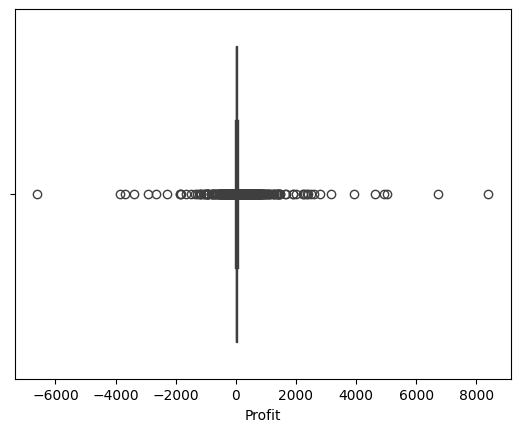

In [18]:
# Outlier lợi nhuận
sns.boxplot(x=df['Profit'])
plt.show()
# tập trung xung quanh điểm 0. có các điểm cực kì lợi nhuận nhưng cũng có các điểm cực kỳ lỗ --> lợi nhuận mỏng --> doanh số ổn nhưng điều quan tâm là lợi nhuận


In [19]:
# Xác định ngưỡng Outlier
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-39.724125 70.816875


In [20]:
#Lọc các đơn hàng lợi nhuận trên điểm upper
profit_outliers = df[df['Profit']> upper]
print(profit_outliers.shape)
print (profit_outliers.head())
#lọc các đơn lỗ dưới diểm lower
loss_outliers = df[df['Profit']<lower]
print(loss_outliers.shape)
print (loss_outliers.head())

# các đơn hàng có lợi nhuận cao và lỗ đậm
# lợi nhuận có sự tương quan với discount không?

(1277, 25)
    Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
1        2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
7        8  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
10      11  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
13      14  CA-2016-161389 2016-12-05 2016-12-10  Standard Class    IM-15070   
24      25  CA-2015-106320 2015-09-25 2015-09-30  Standard Class    EB-13870   

      Customer Name   Segment        Country         City  ... Sub-Category  \
1       Claire Gute  Consumer  United States    Henderson  ...       Chairs   
7   Brosina Hoffman  Consumer  United States  Los Angeles  ...       Phones   
10  Brosina Hoffman  Consumer  United States  Los Angeles  ...       Tables   
13     Irene Maddox  Consumer  United States      Seattle  ...      Binders   
24      Emily Burns  Consumer  United States         Orem  ...       Tables   

                                 

In [21]:
VIP = sales_outliers[sales_outliers['Profit']> upper]
print(VIP.shape)
print (VIP.head())
#danh sách khách hành có sales + lợi nhuận cao --> có danh sách này ta có tệp khách hàng uy tín để phát triển lợi nhuận nhưng vẫn đảm bảo doanh số

(723, 25)
    Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
1        2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
7        8  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
10      11  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
24      25  CA-2015-106320 2015-09-25 2015-09-30  Standard Class    EB-13870   
35      36  CA-2016-117590 2016-12-08 2016-12-10     First Class    GH-14485   

      Customer Name    Segment        Country         City  ... Sub-Category  \
1       Claire Gute   Consumer  United States    Henderson  ...       Chairs   
7   Brosina Hoffman   Consumer  United States  Los Angeles  ...       Phones   
10  Brosina Hoffman   Consumer  United States  Los Angeles  ...       Tables   
24      Emily Burns   Consumer  United States         Orem  ...       Tables   
35        Gene Hale  Corporate  United States   Richardson  ...       Phones   

                            

In [22]:
VIP.to_excel('/content/ggdrive/MyDrive/DATA ANALYST/PROJECT/1.SUPERSTORE/VIP.xlsx', index=False)

print("Đã lưu file VIP.xlsx")

Đã lưu file VIP.xlsx


In [23]:
loss_outliers.to_excel('/content/ggdrive/MyDrive/DATA ANALYST/PROJECT/1.SUPERSTORE/loss_outliers.xlsx', index=False)

print("Đã lưu file loss_outliers.xlsx")

Đã lưu file loss_outliers.xlsx


In [24]:
# Tính hệ số tương quan giữa 2 cột
correlation = df['Profit'].corr(df['Discount'])
print(f"Hệ số tương quan giữa Profit và Discount là: {correlation:.2f}")


Hệ số tương quan giữa Profit và Discount là: -0.22


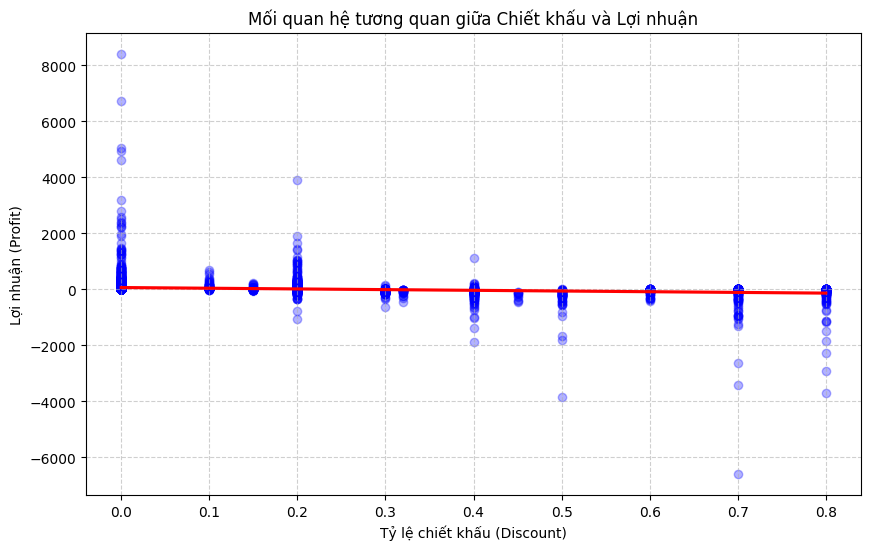

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Vẽ biểu đồ phân tán kèm đường xu hướng tuyến tính
sns.regplot(data=df, x='Discount', y='Profit',scatter_kws={'alpha':0.3, 'color':'blue'},line_kws={'color':'red'})
plt.title('Mối quan hệ tương quan giữa Chiết khấu và Lợi nhuận')
plt.xlabel('Tỷ lệ chiết khấu (Discount)')
plt.ylabel('Lợi nhuận (Profit)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# chiết khấu càng cao --> lợi nhuận càng giảm


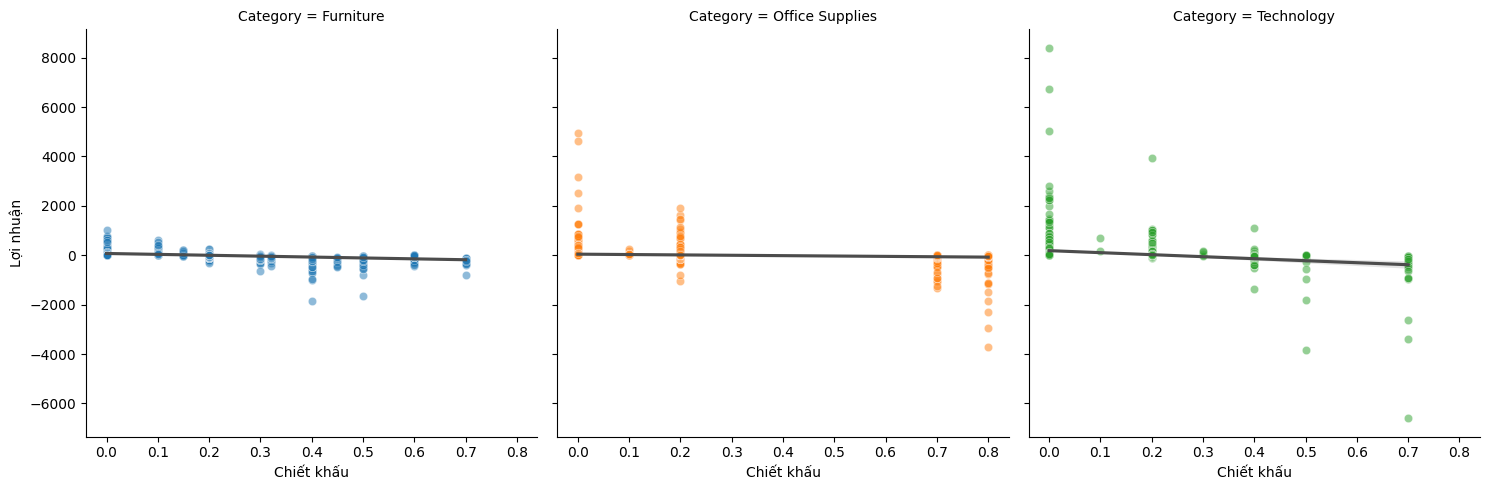

In [26]:
# Vẽ biểu đồ phân tán phân loại theo từng Danh mục sản phẩm
g = sns.FacetGrid(df, col="Category", hue="Category", height=5)
g.map(sns.scatterplot, "Discount", "Profit", alpha=0.5)
g.map(sns.regplot, "Discount", "Profit", scatter=False, color=".3")
g.set_axis_labels("Chiết khấu", "Lợi nhuận")
plt.tight_layout()
plt.show()
# furniture có lợi nhuận mỏng, nhưng không quá lỗ
# office supplies và Technology càng tăng chiết khấu thì càng lỗ đậm.


In [27]:
# chiết khấu bao nhiêu trên mỗi Caregory thì hợp lý
from sklearn.linear_model import LinearRegression
import numpy as np
print("--- Mức chiết khấu hòa vốn lý thuyết (Dự báo bằng Machine Learning) ---")
# Chạy mô hình riêng cho từng Danh mục
for category in df['Category'].unique():
    sub_df = df[df['Category'] == category]
    # Chuẩn bị dữ liệu X (Discount) và y (Profit)
    X = sub_df[['Discount']].values
    y = sub_df['Profit'].values
    # Huấn luyện mô hình
    model = LinearRegression()
    model.fit(X, y)
    alpha = model.intercept_
    # Lợi nhuận khi không chiết khấu
    beta = model.coef_[0]
    # Mức độ giảm lợi nhuận trên mỗi 100% chiết khấu
    # Tính điểm hòa vốn (Profit = 0)
    # Công thức: 0 = alpha + beta * discount => discount = -alpha / beta
    if beta < 0:  # Đảm bảo mối quan hệ là tương quan nghịch
        breakeven_discount = -alpha / beta
        # Giới hạn giá trị trong khoảng từ 0% đến 100% để hợp lý hóa thực tế
        breakeven_discount = max(0.0, min(1.0, breakeven_discount))
        print(f"Danh mục [{category}]: Nên chiết khấu TỐI ĐA {breakeven_discount*100:.2f}% để không bị lỗ.")
    else:
        print(f"Danh mục [{category}]: Không tìm thấy xu hướng giảm lỗ rõ ràng.")


--- Mức chiết khấu hòa vốn lý thuyết (Dự báo bằng Machine Learning) ---
Danh mục [Furniture]: Nên chiết khấu TỐI ĐA 19.79% để không bị lỗ.
Danh mục [Office Supplies]: Nên chiết khấu TỐI ĐA 29.28% để không bị lỗ.
Danh mục [Technology]: Nên chiết khấu TỐI ĐA 22.90% để không bị lỗ.


In [28]:
# THỐNG KÊ TỔNG LỢI NHUẬN THEO BANG (State) - TRÊN TOÀN BỘ ĐƠN HÀNG
# (Khớp với logic chart Power BI: Sum of Profit by State, không lọc loss_outliers)

total_profit_by_state = df.groupby('State')['Profit'].sum().sort_values()
top_loss_locations = total_profit_by_state.head()
# 5 bang có tổng Profit thấp nhất (âm nhiều nhất)
top_loss_locations


,Profit
State,
Texas,-25729.3563
Ohio,-16971.3766
Pennsylvania,-15559.9603
Illinois,-12607.8870
North Carolina,-7490.9122


## 3.3 Kiểm tra outlier cho giá từng sản phẩm

In [29]:
# Kiểm tra Sales theo từng Product Name
# Tạo các biến Unit_price: giá trên 1 đơn vị, Unit_Profit: lợi nhuận trên 1 đơn vị, Actual_Margin_Rate: biên lợi nhuận trên một đơn vị
df['Unit_Price'] = (df['Sales'] /(df['Quantity'] * (1 - df['Discount'])))
df['Unit_Profit'] = df['Profit'] / df['Quantity']
df['Actual_Margin_Rate'] = df['Unit_Profit'] / df['Unit_Price']

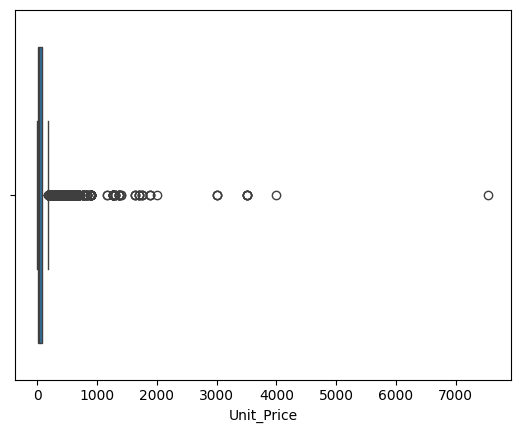

In [30]:
sns.boxplot(x=df['Unit_Price'])
plt.show()

In [31]:
#Gom nhóm theo sản phẩm và tính thông kê
price_variation = (df.groupby('Product Name')['Unit_Price'].agg(['count', 'min', 'max', 'mean', 'std']).reset_index())
#Tính khoảng dao động giá
price_variation['Price_Range'] = (price_variation['max'] - price_variation['min'])
#Phần trăm dao động giá
price_variation['Range_%'] = (price_variation['Price_Range']/ price_variation['mean'] * 100)
price_variation.sort_values('Range_%',ascending=False).head(20)
#cùng một sản phẩm được bán với nhiều mức Unit Price khác nhau

,Product Name,count,min,max,mean,std,Price_Range,Range_%
537,Easy-staple paper,46,4.28,55.98,19.816957,1.455485e+01,5.170000e+01,2.608877e+02
1493,Staple envelope,48,5.58,30.98,10.455000,6.594082e+00,2.540000e+01,2.429460e+02
1500,Staples in misc. colors,19,1.78,11.97,6.353684,3.501076e+00,1.019000e+01,1.603794e+02
1499,Staples,46,1.88,7.89,4.215652,2.033236e+00,6.010000e+00,1.425639e+02
1496,Staple remover,18,2.18,7.98,4.135556,2.219227e+00,5.800000e+00,1.402472e+02
591,Eldon Wave Desk Accessories,14,2.08,5.89,4.529286,1.894504e+00,3.810000e+00,8.411922e+01
1494,Staple holder,13,8.67,11.97,10.650000,1.438437e+00,3.300000e+00,3.098592e+01
1497,Staple-based wall hangings,16,7.96,9.74,8.627500,8.900000e-01,1.780000e+00,2.063170e+01
1495,Staple magnet,10,9.38,10.68,9.770000,6.279597e-01,1.300000e+00,1.330604e+01
925,Insertable Tab Post Binder Dividers,8,8.02,8.02,8.020000,1.644587e-15,5.329071e-15,6.644726e-14


# 4. PHÂN TÍCH PHÂN PHỐI DỮ LIỆU

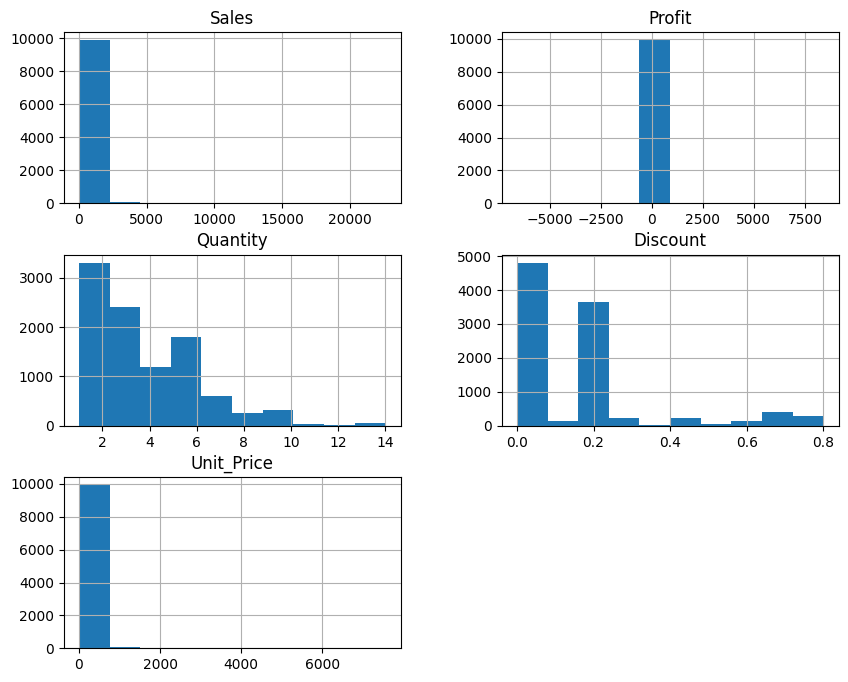

In [ ]:
# biểu diễn phối của doanh số, lợi nhuận, số lượng, chiết khấu, giá bán
df[['Sales','Profit','Quantity','Discount','Unit_Price']].hist(figsize=(10,8))
plt.show()
#sales và Unite_price: lệch phải nặng. đa số sản phẩm giá thấp (có một vài đơn hàng giá cao đến rất cao)
#Profit: tập trung ở trung tâm xung quanh điểm 0, đa số các đơn hàng đem lại lợi nhuận nhỏ hòa có đơn dẫn đến lỗ


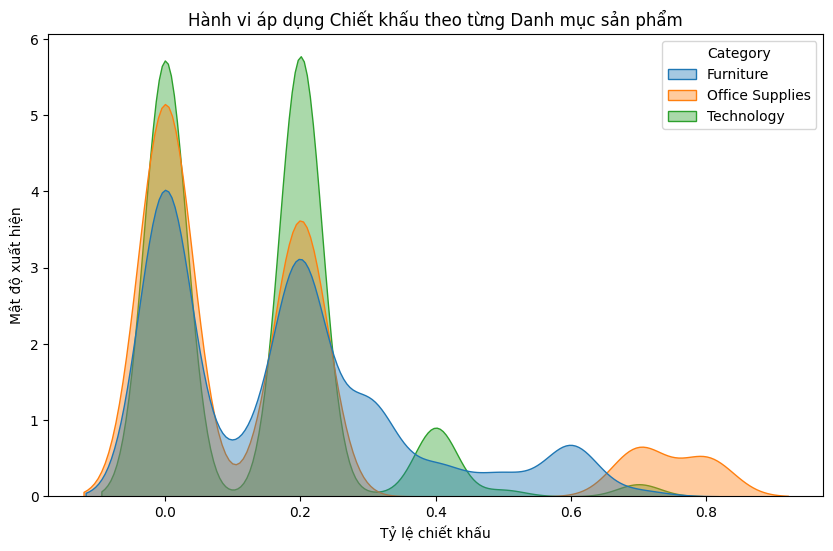

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Vẽ biểu đồ mật độ phân phối Discount, tách màu theo Category
sns.kdeplot(data=df, x='Discount', hue='Category', fill=True, common_norm=False, alpha=0.4)
plt.title('Hành vi áp dụng Chiết khấu theo từng Danh mục sản phẩm')
plt.xlabel('Tỷ lệ chiết khấu')
plt.ylabel('Mật độ xuất hiện')
plt.show()


In [ ]:
# sự tương quang
import pandas as pd
# Chọn các cột số cốt lõi để phân tích tương quan
# Bao gồm cả biến Unit_Price gốc đã tính ở bước trước
commercial_features = df[['Sales', 'Profit', 'Quantity', 'Discount', 'Unit_Price']]
# Tính toán ma trận tương quan
corr_matrix = commercial_features.corr()
# Hiển thị bảng ma trận
print("Ma trận tương quan giữa các biến:")
print(corr_matrix.round(2))


Ma trận tương quan giữa các biến:
            Sales  Profit  Quantity  Discount  Unit_Price
Sales        1.00    0.48      0.20     -0.03        0.86
Profit       0.48    1.00      0.07     -0.22        0.20
Quantity     0.20    0.07      1.00      0.01        0.00
Discount    -0.03   -0.22      0.01      1.00        0.07
Unit_Price   0.86    0.20      0.00      0.07        1.00


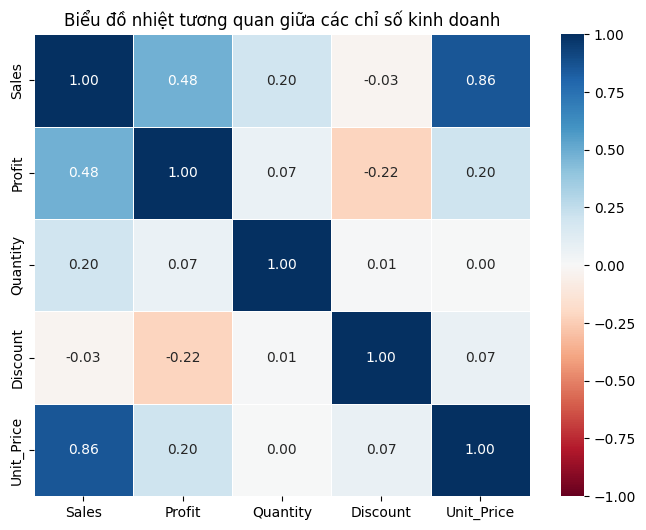

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
# Vẽ biểu đồ nhiệt với bảng màu từ Đỏ (Nghịch) sang Xanh (Thuận)
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Biểu đồ nhiệt tương quan giữa các chỉ số kinh doanh')
plt.show()
#Mối quan hệ giữa Discount và Profit: Tương quan Nghịch
#Mối quan hệ giữa Sales và Profit :Tương quan Thuận
#Mối quan hệ giữa Discount và Quantity :Chỉ số thực tế: Thường rất gần 0.01. Hệ số gần bằng 0 chứng tỏ việc giảm giá gần như KHÔNG làm tăng số lượng sản phẩm


In [ ]:
#Phân tích tương quan sâu  theo từng Danh mục con (Sub-Category).
import pandas as pd
# Tạo một danh sách để lưu kết quả
sub_category_corr = []
# Duyệt qua từng Sub-Category để tính tương quan
for sub_cat, sub_df in df.groupby('Sub-Category'):
    # Tính tương quan giữa Discount và Profit cho các nhóm riêng
    correlation = sub_df['Discount'].corr(sub_df['Profit'])
    # Tính thêm Lợi nhuận tổng để xem mức độ thiệt hại thực tế
    total_profit = sub_df['Profit'].sum()
    sub_category_corr.append({'Sub-Category': sub_cat,'Correlation_Discount_Profit': correlation,'Total_Profit_USD': total_profit})
# Chuyển thành DataFrame để dễ quan sát và sắp xếp
df_analysis = pd.DataFrame(sub_category_corr)
# Sắp xếp từ tương quan âm nặng nhất (nguy hiểm nhất)
df_analysis = df_analysis.sort_values(by='Correlation_Discount_Profit')
print("--- BẢNG XẾP HẠNG MỨC ĐỘ NGUY HIỂM CỦA CHIẾT KHẤU THEO MẶT HÀNG ---")
print(df_analysis.to_string(index=False))
#Nhóm Tương quan âm nặng (Gần -0.7 đến -0.8): Thường là Tables (Bàn), Bookcases (Giá sách)


--- BẢNG XẾP HẠNG MỨC ĐỘ NGUY HIỂM CỦA CHIẾT KHẤU THEO MẶT HÀNG ---
Sub-Category  Correlation_Discount_Profit  Total_Profit_USD
      Tables                    -0.671770       -17725.4811
   Bookcases                    -0.607067        -3472.5560
      Chairs                    -0.591815        26590.1663
    Machines                    -0.582508         3384.7569
  Appliances                    -0.495198        18138.0054
 Furnishings                    -0.471598        13059.1436
      Phones                    -0.469341        44515.7306
     Storage                    -0.364029        21278.8264
     Copiers                    -0.356122        55617.8249
    Supplies                    -0.253066        -1189.0995
         Art                    -0.251636         6527.7870
 Accessories                    -0.244192        41936.6357
     Binders                    -0.238195        30221.7633
   Envelopes                    -0.184235         6964.1767
       Paper                    

/tmp/ipykernel_5174/1873212323.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_analysis,y='Sub-Category',x='Correlation_Discount_Profit', palette='vlag') # Màu đỏ cho âm, xanh cho dương)


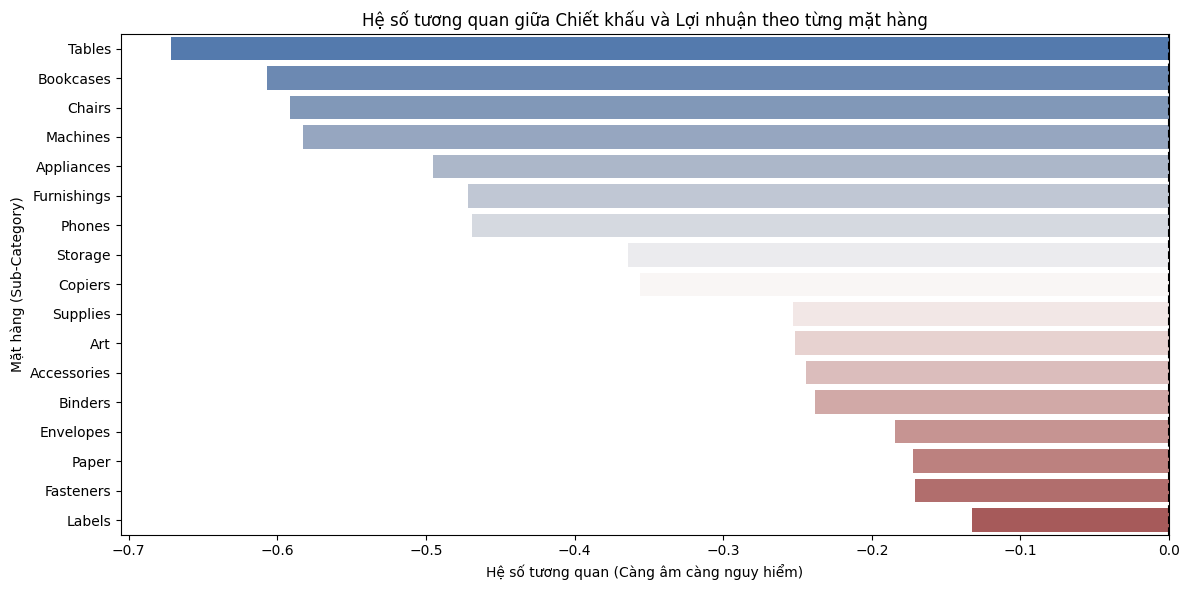

In [ ]:
#Trực quan hóa kết quả bằng biểu đồ thanh (Barplot) để báo cáo
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
# Vẽ biểu đồ thanh
sns.barplot(data=df_analysis,y='Sub-Category',x='Correlation_Discount_Profit', palette='vlag') # Màu đỏ cho âm, xanh cho dương)
plt.axvline(0, color='black', linestyle='--')
plt.title('Hệ số tương quan giữa Chiết khấu và Lợi nhuận theo từng mặt hàng')
plt.xlabel('Hệ số tương quan (Càng âm càng nguy hiểm)')
plt.ylabel('Mặt hàng (Sub-Category)')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
# Nhóm dữ liệu theo Vùng miền
region_summary = df.groupby('Region').agg(
    Average_Discount=('Discount', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'count')
).reset_index()
# Tính tỷ suất lợi nhuận (Profit Margin = Profit / Sales) để so sánh sòng phẳng
region_summary['Profit_Margin_%'] = (region_summary['Total_Profit'] / region_summary['Total_Sales']) * 100
region_summary = region_summary.sort_values(by='Average_Discount', ascending=False)

print("--- THỐNG KÊ HIỆU QUẢ KINH DOANH THEO VÙNG MIỀN ---")
print(region_summary.to_string(index=False, formatters={'Average_Discount': '{:.2%}'.format,'Total_Sales': '${:,.2f}'.format,'Total_Profit': '${:,.2f}'.format,'Profit_Margin_%': '{:.2f}%'.format}))
#Central : có Average_Discount cao = 24.04% nhưng Profit_Margin_% thấp chỉ 7.92%

--- THỐNG KÊ HIỆU QUẢ KINH DOANH THEO VÙNG MIỀN ---
 Region Average_Discount Total_Sales Total_Profit  Total_Orders Profit_Margin_%
Central           24.04% $501,239.89   $39,706.36          2323           7.92%
  South           14.73% $391,721.91   $46,749.43          1620          11.93%
   East           14.54% $678,781.24   $91,522.78          2848          13.48%
   West           10.93% $725,457.82  $108,418.45          3203          14.94%


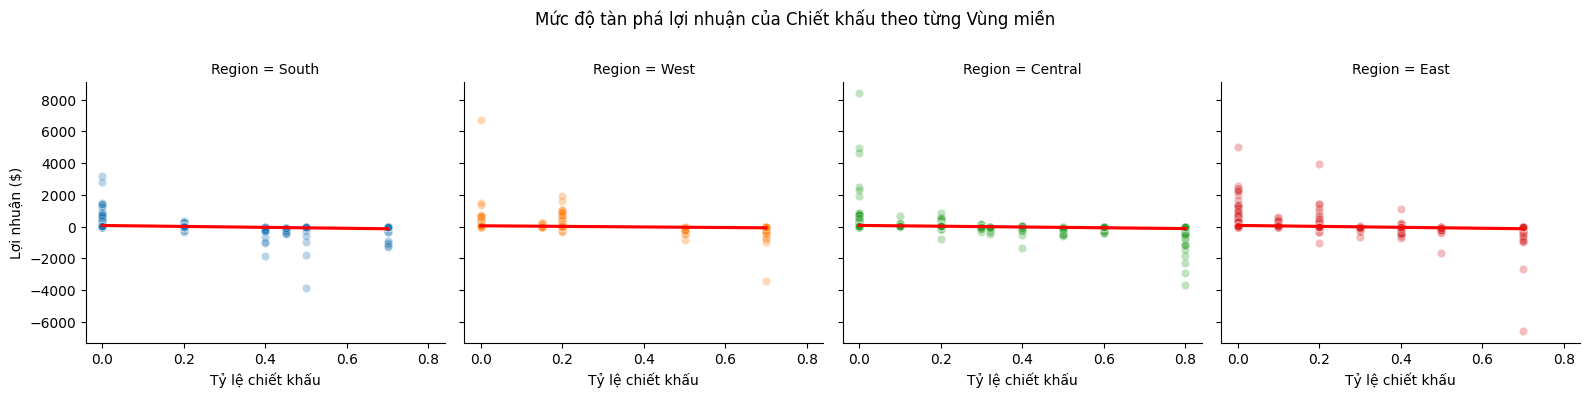

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ biểu đồ phân tán phân mảnh theo vùng miền (FacetGrid)
g = sns.FacetGrid(df, col="Region", hue="Region", height=4, aspect=1)
g.map(sns.scatterplot, "Discount", "Profit", alpha=0.3)
g.map(sns.regplot, "Discount", "Profit", scatter=False, color="red") # Đường xu hướng màu đỏ

g.set_axis_labels("Tỷ lệ chiết khấu", "Lợi nhuận ($)")
plt.subplots_adjust(top=0.8)
g.fig.suptitle('Mức độ tàn phá lợi nhuận của Chiết khấu theo từng Vùng miền')
plt.show()


tìm hiểu sâu hơn xuống cấp Bang (State) hoặc Thành phố (City) cụ thể nào đang lỗ nặng nhất không?

In [ ]:
#Tìm Top 10 Bang (State) đang gánh khoản lỗ nặng nhất
import pandas as pd

# 1. Gom nhóm theo Bang để tính Tổng lợi nhuận và Chiết khấu trung bình
state_summary = df.groupby('State').agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Order_Count=('Order ID', 'count')
).reset_index()

# 2. Lọc ra các bang bị lỗ (Total_Profit < 0) và sắp xếp từ lỗ nặng nhất xuống
loss_states = state_summary[state_summary['Total_Profit'] < 0].sort_values(by='Total_Profit')

print("--- TOP CÁC BANG ĐANG BỊ THUA LỖ NẶNG NHẤT ---")
print(loss_states.head(10).to_string(index=False, formatters={
    'Total_Profit': '${:,.2f}'.format,
    'Total_Sales': '${:,.2f}'.format,
    'Avg_Discount': '{:.2%}'.format
}))


--- TOP CÁC BANG ĐANG BỊ THUA LỖ NẶNG NHẤT ---
         State Total_Profit Total_Sales Avg_Discount  Order_Count
         Texas  $-25,729.36 $170,188.05       37.02%          985
          Ohio  $-16,971.38  $78,258.14       32.49%          469
  Pennsylvania  $-15,559.96 $116,511.91       32.86%          587
      Illinois  $-12,607.89  $80,166.10       39.00%          492
North Carolina   $-7,490.91  $55,603.16       28.35%          249
      Colorado   $-6,527.86  $32,108.12       31.65%          182
     Tennessee   $-5,341.69  $30,661.87       29.13%          183
       Arizona   $-3,427.92  $35,282.00       30.36%          224
       Florida   $-3,399.30  $89,473.71       29.93%          383
        Oregon   $-1,190.47  $17,431.15       28.87%          124


In [ ]:
# Đào sâu xuống Top 10 Thành phố (City) "báo động đỏ"
# Gom nhóm theo Thành phố và kèm theo Bang của nó để không bị trùng tên thành phố
city_summary = df.groupby(['City', 'State']).agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Avg_Discount=('Discount', 'mean')
).reset_index()

# Sắp xếp tìm ra 10 thành phố lỗ sâu nhất hệ thống
top_loss_cities = city_summary.sort_values(by='Total_Profit').head(10)

print("\n--- TOP 10 THÀNH PHỐ ĐANG LỖ NẶNG NHẤT HỆ THỐNG ---")
print(top_loss_cities.to_string(index=False, formatters={
    'Total_Profit': '${:,.2f}'.format,
    'Total_Sales': '${:,.2f}'.format,
    'Avg_Discount': '{:.2%}'.format
}))



--- TOP 10 THÀNH PHỐ ĐANG LỖ NẶNG NHẤT HỆ THỐNG ---
        City          State Total_Profit Total_Sales Avg_Discount
Philadelphia   Pennsylvania  $-13,837.77 $109,077.01       32.68%
     Houston          Texas  $-10,153.55  $64,504.76       37.97%
 San Antonio          Texas   $-7,299.05  $21,843.53       38.31%
   Lancaster           Ohio   $-7,149.62   $8,202.62       31.29%
     Chicago       Illinois   $-6,654.57  $48,539.54       38.38%
  Burlington North Carolina   $-5,894.53  $12,681.28       30.91%
  Louisville       Colorado   $-3,406.21   $5,070.42       33.75%
      Dallas          Texas   $-2,846.53  $20,131.93       35.86%
     Phoenix        Arizona   $-2,790.88  $11,000.26       35.40%
Jacksonville        Florida   $-2,445.66  $39,133.33       28.47%


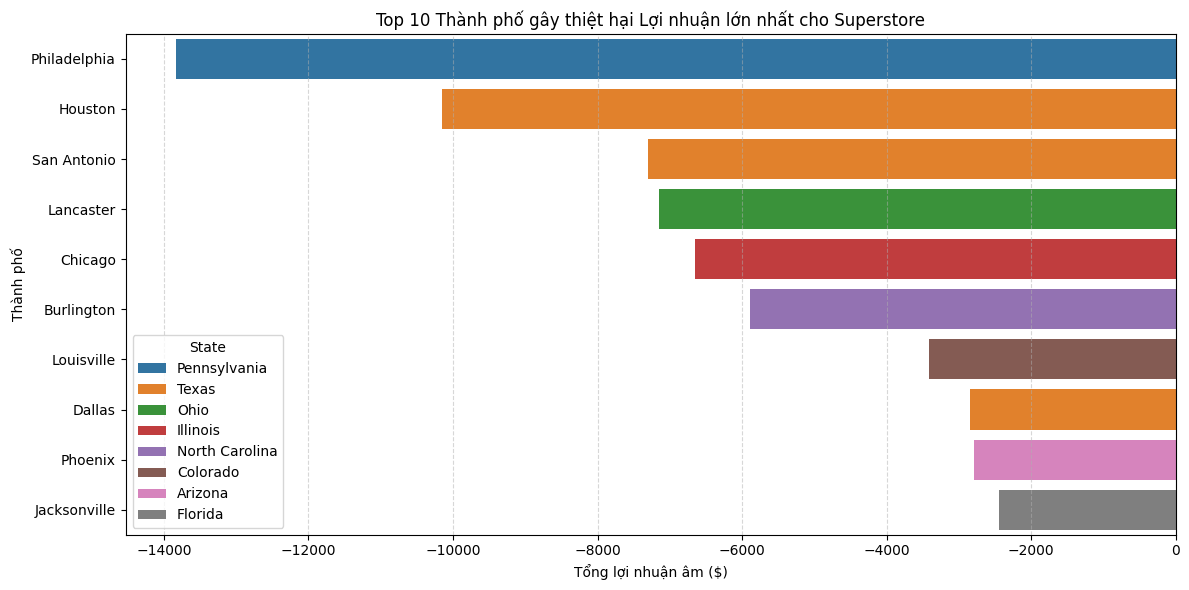

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Vẽ biểu đồ thanh ngang cho các thành phố lỗ nặng nhất
sns.barplot(data=top_loss_cities,y='City',x='Total_Profit',hue='State',dodge=False)
plt.title('Top 10 Thành phố gây thiệt hại Lợi nhuận lớn nhất cho Superstore')
plt.xlabel('Tổng lợi nhuận âm ($)')
plt.ylabel('Thành phố')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
